<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/MarketMicrostructure/MarketMicrostructure/Adverse_Selection_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

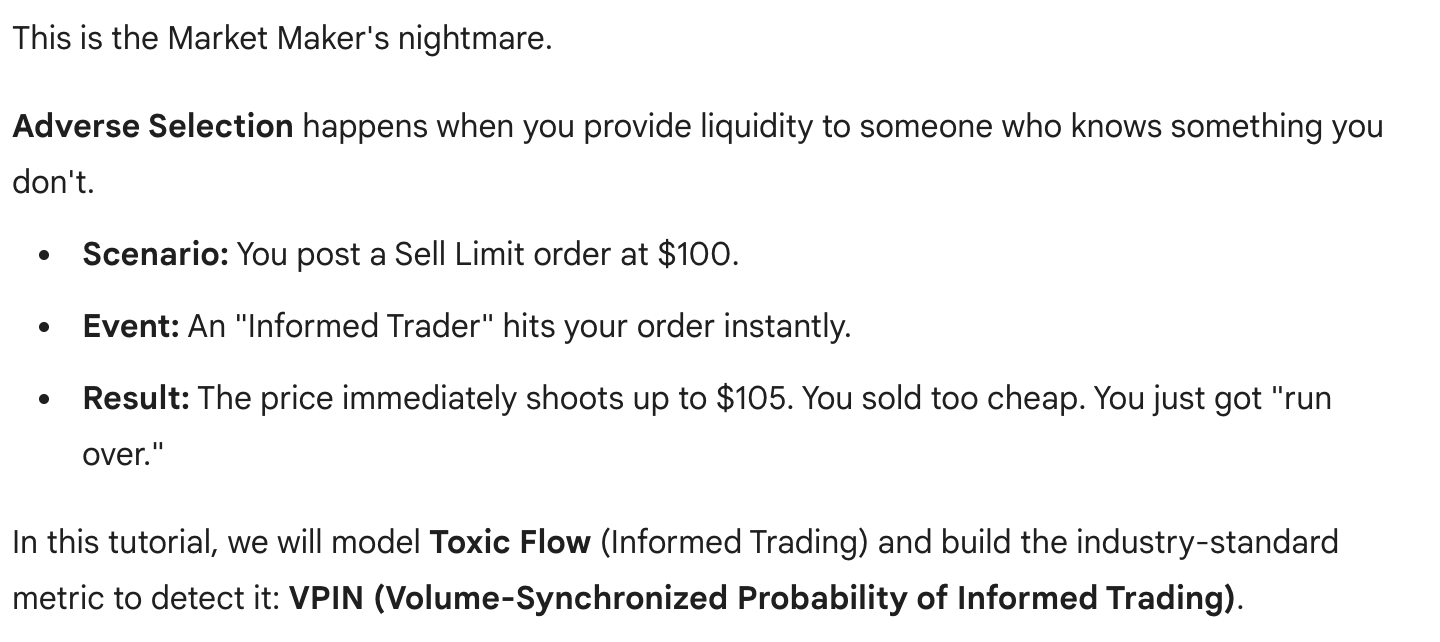

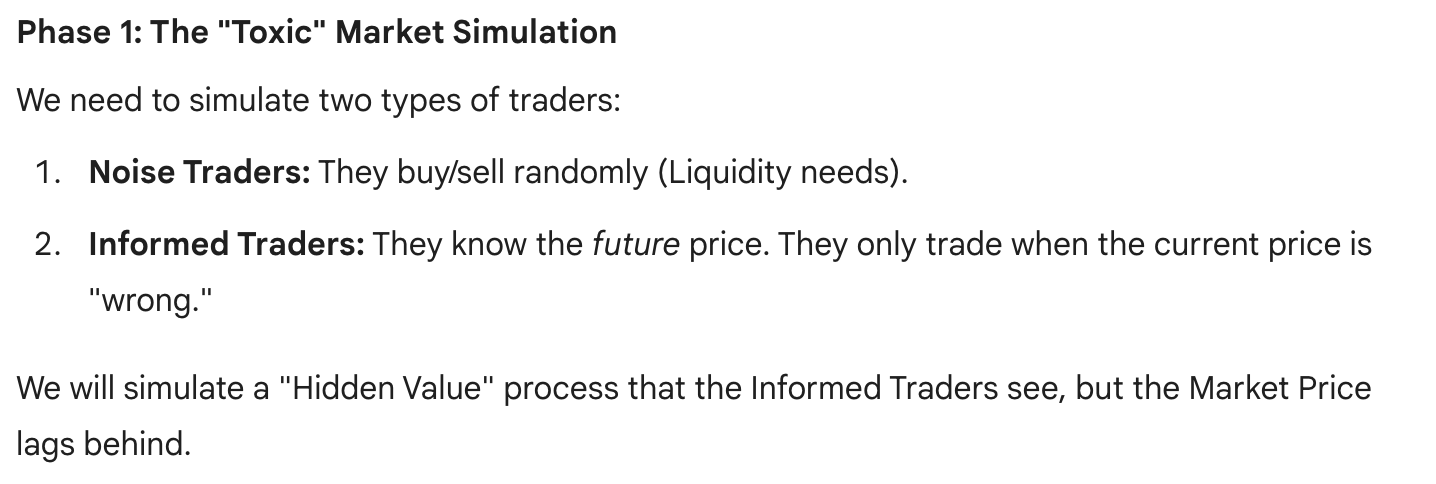

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# --- CONFIGURATION ---
N_TICKS = 5000
NOISE_RATIO = 0.7  # 70% of trades are random
INFORMED_RATIO = 0.3 # 30% are toxic

In [3]:
def generate_toxic_market():
    np.random.seed(42)

    # 1. The "True" Fundamental Value (Random Walk)
    # This is what Informed Traders know.
    true_returns = np.random.normal(0, 0.05, N_TICKS)
    true_price = 100.0 + np.cumsum(true_returns)

    # 2. The Market Price (Lags behind True Price)
    # Market Makers are slow to update.
    market_price = np.zeros(N_TICKS)
    market_price[0] = 100.0

    trades = []

    for t in range(1, N_TICKS):
        # Market Maker updates price slowly (simple moving average logic or lagged)
        # Here we assume MM catches up by 20% of the difference each step
        market_price[t] = market_price[t-1] + 0.2 * (true_price[t-1] - market_price[t-1])

        # 3. Determine Who Trades
        is_informed = np.random.rand() < INFORMED_RATIO

        trade_dir = 0 # +1 Buy, -1 Sell
        trade_type = "Noise"

        if is_informed:
            # Informed Trader: Buys if True > Market, Sells if True < Market
            gap = true_price[t] - market_price[t]
            if abs(gap) > 0.05: # Only trade if edge is sufficient
                trade_dir = np.sign(gap)
                trade_type = "Informed"
            else:
                trade_dir = 0 # No edge, no trade
        else:
            # Noise Trader: Random coin flip
            trade_dir = 1 if np.random.rand() > 0.5 else -1
            trade_type = "Noise"

        if trade_dir != 0:
            trades.append({
                'Time': t,
                'True_Price': true_price[t],
                'Market_Price': market_price[t],
                'Side': trade_dir, # 1=Buy, -1=Sell
                'Type': trade_type,
                'Volume': np.random.randint(1, 10) * (5 if trade_type == "Informed" else 1) # Informed trade larger
            })

    return pd.DataFrame(trades)

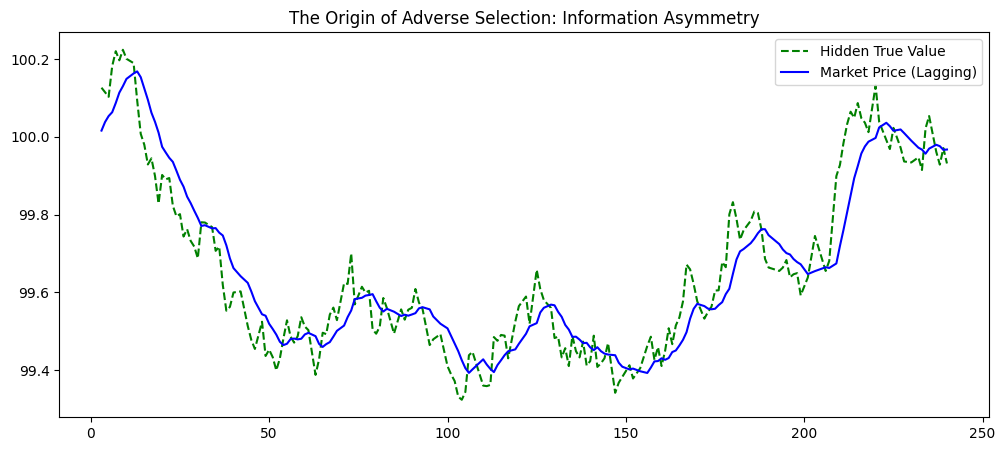

In [4]:
df = generate_toxic_market()

# --- VISUALIZE THE INFORMATION GAP ---
plt.figure(figsize=(12, 5))
plt.plot(df['Time'][:200], df['True_Price'][:200], label='Hidden True Value', color='green', linestyle='--')
plt.plot(df['Time'][:200], df['Market_Price'][:200], label='Market Price (Lagging)', color='blue')
plt.title("The Origin of Adverse Selection: Information Asymmetry")
plt.legend()
plt.show()

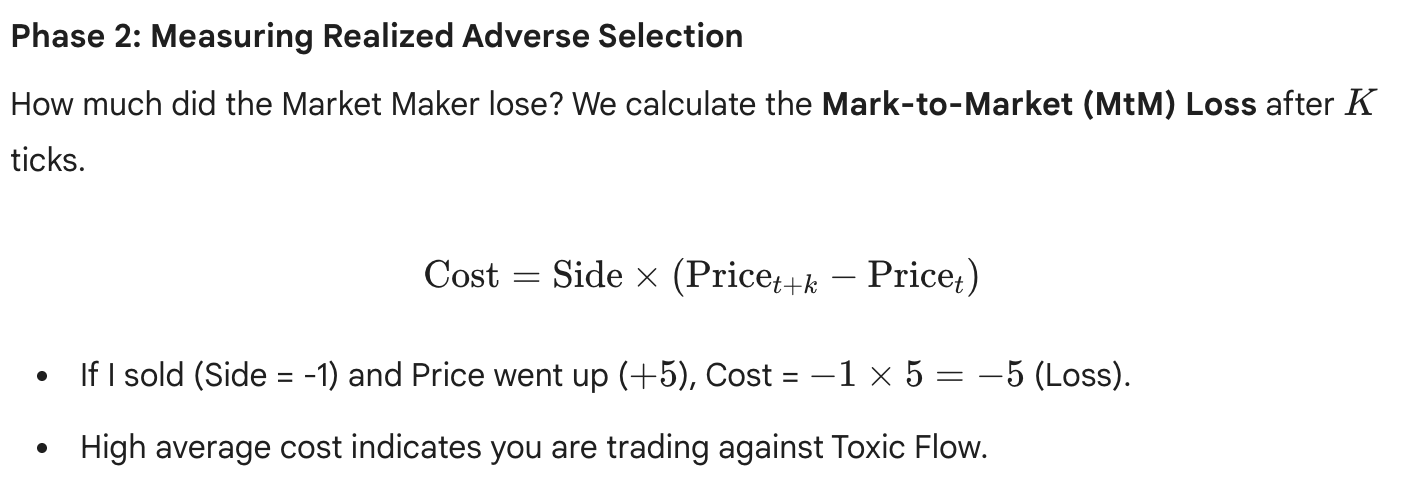

In [5]:
def calculate_realized_toxicity(df, lookahead=20):
    df = df.copy()

    # Future price (k ticks later)
    # In real HFT, this would be time-based (e.g., 5 seconds later)
    df['Future_Price'] = df['Market_Price'].shift(-lookahead)

    # Adverse Selection metric
    # Note: From MM perspective. MM takes opposite side of trade.
    # If Trader Buys (Side 1), MM Sells.
    # MM PnL = (Price_now - Price_future) * Trader_Side
    # Example: Trader buys at 100. Price goes to 105. MM is Short at 100. MM loses 5.
    df['MM_PnL'] = (df['Market_Price'] - df['Future_Price']) * df['Side']

    return df.dropna()

In [6]:
analyzed_df = calculate_realized_toxicity(df)

# Compare Noise vs Informed Costs
grp = analyzed_df.groupby('Type')['MM_PnL'].mean()

print("📊 Average Market Maker PnL per Trade:")
print(f"   -> Against Noise Traders:    ${grp['Noise']:.4f} (Spread capture)")
print(f"   -> Against Informed Traders: ${grp['Informed']:.4f} (Adverse Selection)")

📊 Average Market Maker PnL per Trade:
   -> Against Noise Traders:    $-0.0026 (Spread capture)
   -> Against Informed Traders: $-0.1091 (Adverse Selection)


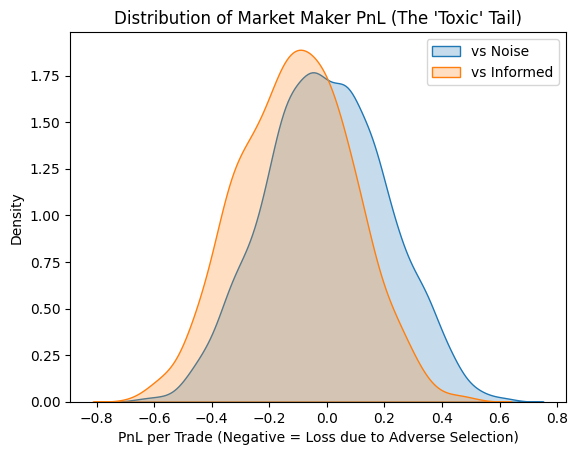

In [7]:
# Visualization
sns.kdeplot(analyzed_df[analyzed_df['Type']=='Noise']['MM_PnL'], label='vs Noise', fill=True)
sns.kdeplot(analyzed_df[analyzed_df['Type']=='Informed']['MM_PnL'], label='vs Informed', fill=True)
plt.title("Distribution of Market Maker PnL (The 'Toxic' Tail)")
plt.xlabel("PnL per Trade (Negative = Loss due to Adverse Selection)")
plt.legend()
plt.show()

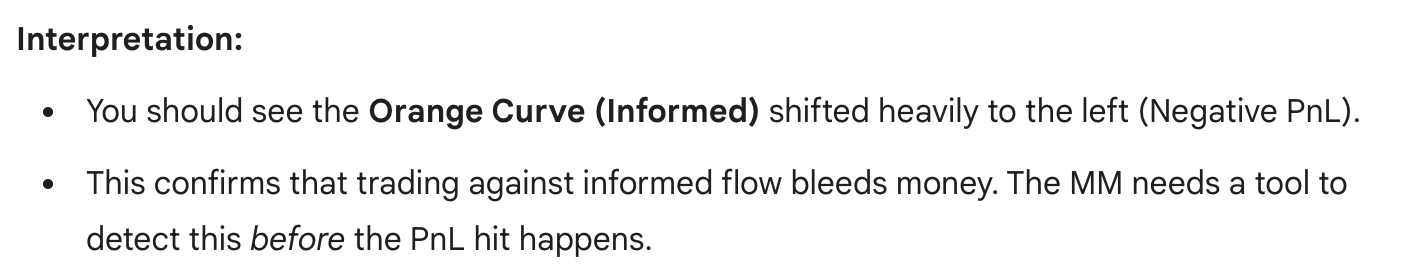

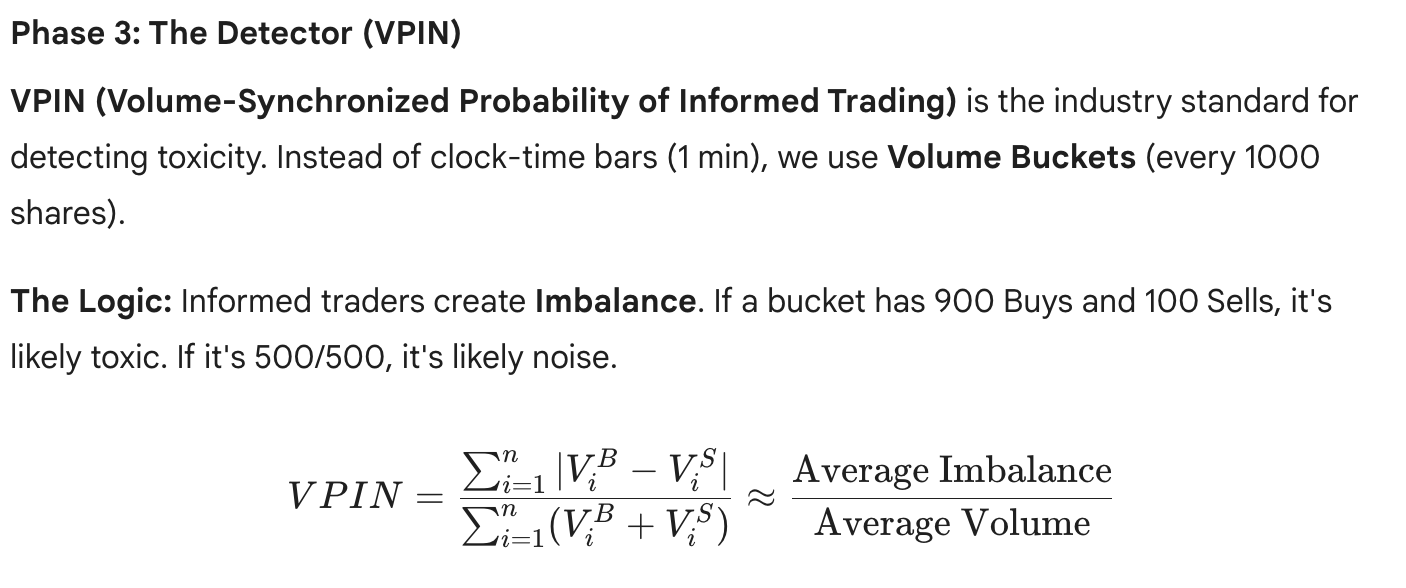

In [8]:
def calculate_vpin(df, bucket_volume=100, window=50):
    """
    1. Group trades into Volume Buckets.
    2. Calculate Order Flow Imbalance (OFI) per bucket.
    3. Smooth it to get VPIN.
    """
    # Simple bucket assignment
    df['Cum_Vol'] = df['Volume'].cumsum()
    df['Bucket_ID'] = (df['Cum_Vol'] // bucket_volume).astype(int)

    # Aggregate per bucket
    buckets = df.groupby('Bucket_ID').apply(
        lambda x: pd.Series({
            'Buy_Vol': x.loc[x['Side']==1, 'Volume'].sum(),
            'Sell_Vol': x.loc[x['Side']==-1, 'Volume'].sum(),
            'Total_Vol': x['Volume'].sum(),
            'Time': x['Time'].max() # Timestamp of bucket close
        })
    ).reset_index()

    # Calculate Absolute Imbalance
    buckets['Imbalance'] = (buckets['Buy_Vol'] - buckets['Sell_Vol']).abs()

    # VPIN is the Rolling Average of (% Imbalance)
    # VPIN = Rolling_Sum(Imbalance) / Rolling_Sum(Total_Vol)
    # Using a rolling window of 'window' buckets

    roll_imbalance = buckets['Imbalance'].rolling(window).sum()
    roll_volume = buckets['Total_Vol'].rolling(window).sum()

    buckets['VPIN'] = roll_imbalance / roll_volume

    return buckets.dropna()

In [9]:
vpin_df = calculate_vpin(df, bucket_volume=50, window=20)

# --- VISUALIZE VPIN SPIKES ---
# Let's verify if VPIN spikes when Informed trading is heavy
# We can approximate "Informed Intensity" by checking the % of informed trades in the bucket
df['IsInformed'] = (df['Type'] == 'Informed').astype(int)
informed_density = df.groupby('Bucket_ID')['IsInformed'].mean()

/tmp/ipython-input-2949406376.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  buckets = df.groupby('Bucket_ID').apply(


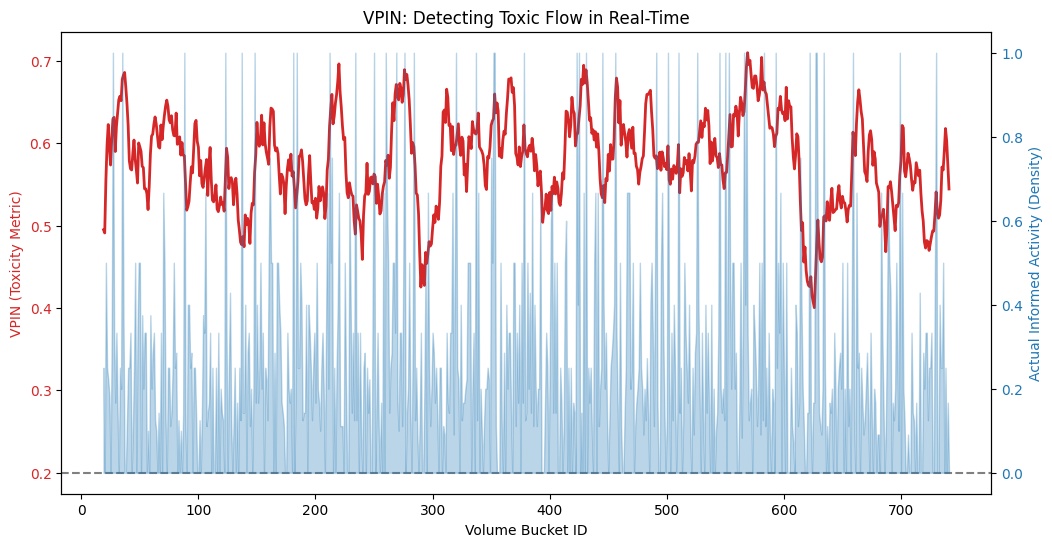

In [10]:
# Merge for plotting
plot_data = vpin_df.merge(informed_density.rename('Informed_Density'), on='Bucket_ID')

fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:red'
ax1.set_xlabel('Volume Bucket ID')
ax1.set_ylabel('VPIN (Toxicity Metric)', color=color)
ax1.plot(plot_data['Bucket_ID'], plot_data['VPIN'], color=color, linewidth=2, label='VPIN')
ax1.tick_params(axis='y', labelcolor=color)
ax1.axhline(0.2, color='gray', linestyle='--', label='Toxicity Threshold')

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Actual Informed Activity (Density)', color=color)
ax2.fill_between(plot_data['Bucket_ID'], plot_data['Informed_Density'], color=color, alpha=0.3, label='Informed Trader %')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("VPIN: Detecting Toxic Flow in Real-Time")
plt.show()

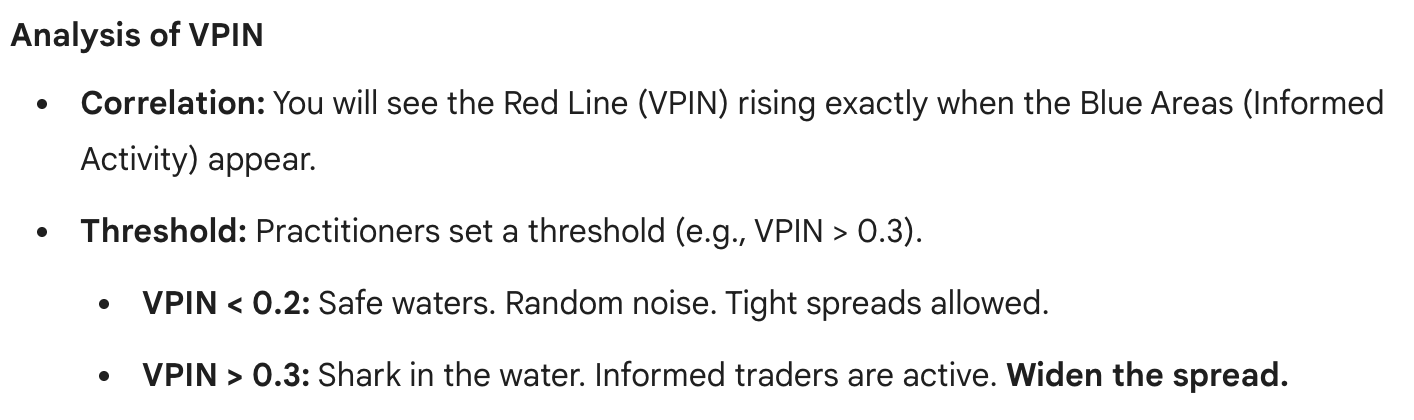

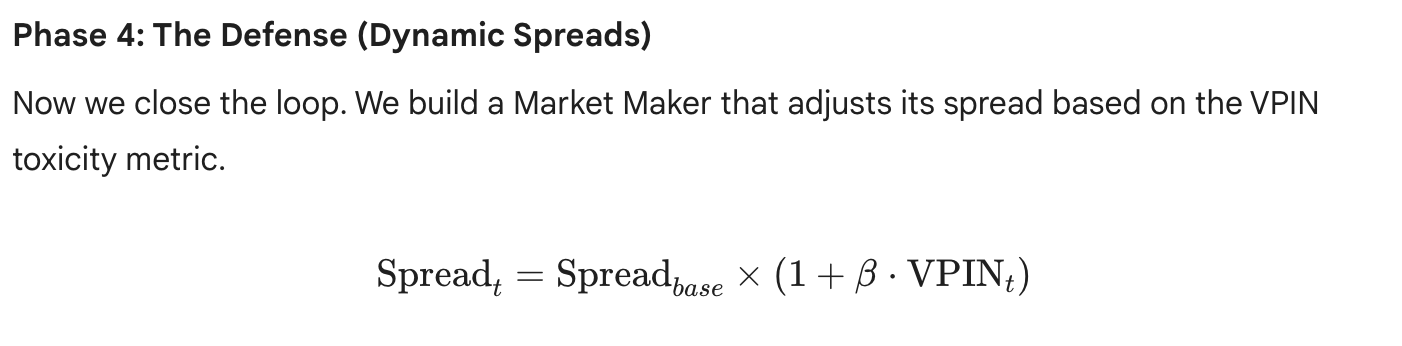

In [12]:
def simulate_defense(vpin_data, base_spread=0.05, sensitivity=5.0):
    """
    Simulates how spread would adapt to toxicity.
    """
    # Calculate Dynamic Spread
    vpin_data['Dynamic_Spread'] = base_spread * (1 + sensitivity * vpin_data['VPIN'])

    # Plotting
    plt.figure(figsize=(12, 5))
    plt.plot(vpin_data['Bucket_ID'], vpin_data['Dynamic_Spread'], color='purple', label='Defensive Spread')
    plt.axhline(base_spread, color='black', linestyle='--', label='Base Spread (Risk Neutral)')

    # Highlight Toxic Zones
    toxic_zones = vpin_data[vpin_data['VPIN'] > 0.25]
    plt.scatter(toxic_zones['Bucket_ID'], toxic_zones['Dynamic_Spread'], color='red', s=10, label='High Toxicity Defense')

    plt.title("Adverse Selection Defense: Dynamic Spread Widening")
    plt.xlabel("Volume Bucket")
    plt.ylabel("Quoted Spread ($)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

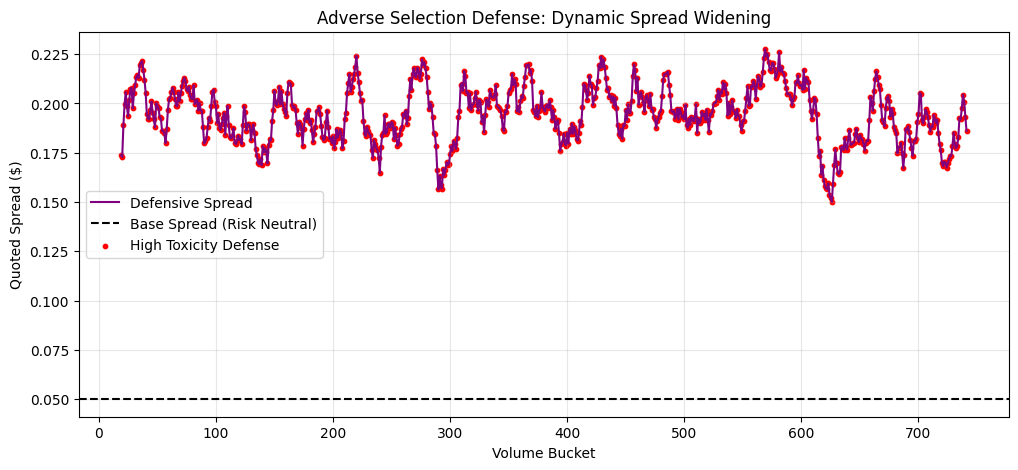

In [13]:
simulate_defense(vpin_df)

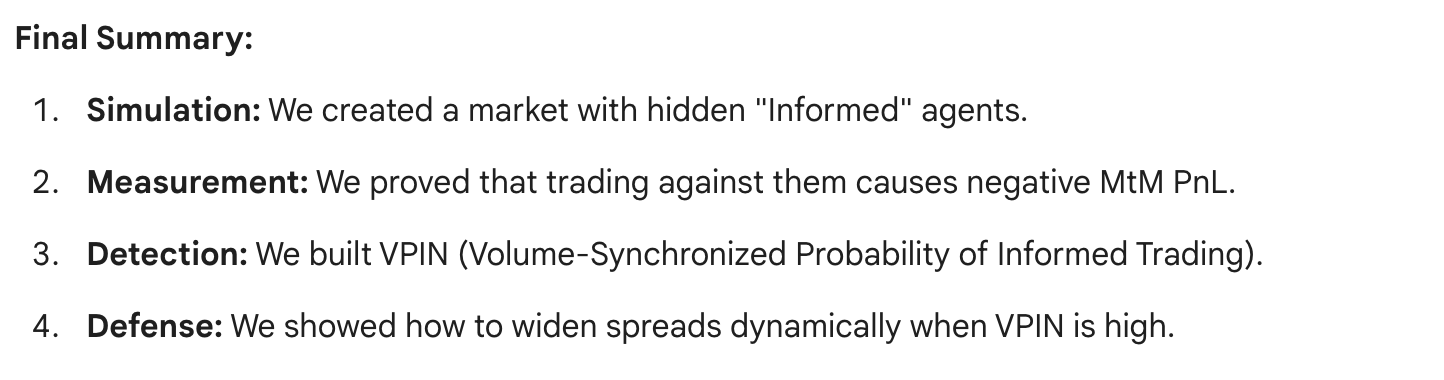